In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# EDA

In [4]:
df.shape

(918, 12)

In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
# EDA & DataCleaning

df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

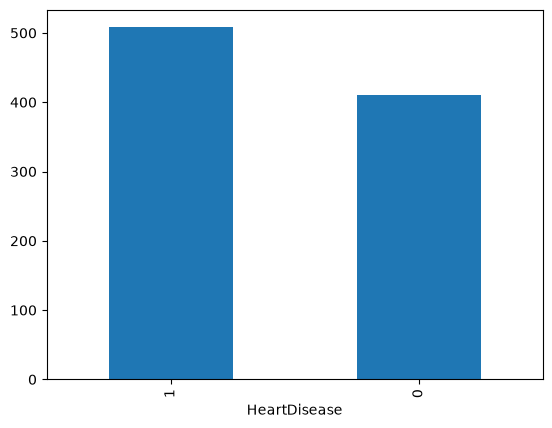

In [9]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [10]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

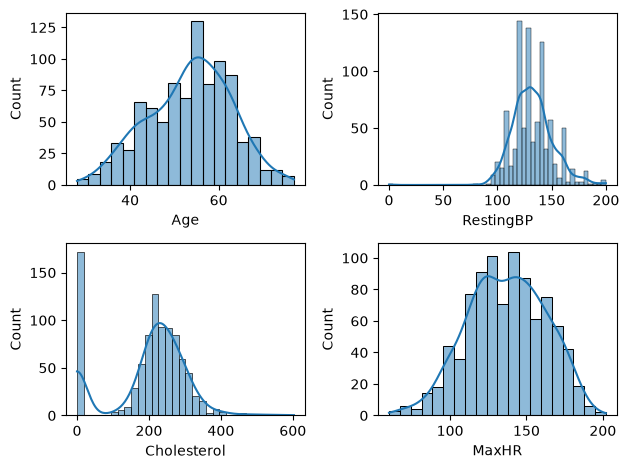

In [11]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var], kde=True)
    
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

In [12]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [13]:
df['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
174      1
117      1
192      1
129      1
164      1
Name: count, Length: 67, dtype: int64

In [14]:
# Cleaning the data to fill the anomolies

ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [15]:
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean).round(2)
df['Cholesterol']

0      289.0
1      180.0
2      283.0
3      214.0
4      195.0
       ...  
913    264.0
914    193.0
915    131.0
916    236.0
917    175.0
Name: Cholesterol, Length: 918, dtype: float64

In [16]:
rBp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0, rBp_mean).round(2)
df['RestingBP']

0      140.0
1      160.0
2      130.0
3      138.0
4      150.0
       ...  
913    110.0
914    144.0
915    130.0
916    130.0
917    138.0
Name: RestingBP, Length: 918, dtype: float64

In [17]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


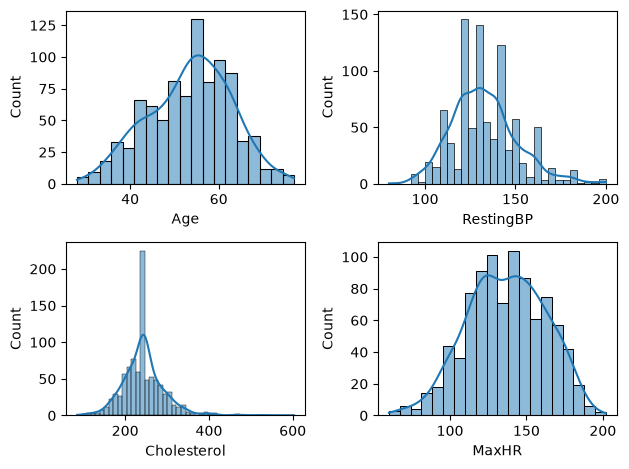

In [18]:
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

In [19]:
import sheryanalysis as sh

sh.analyze(df)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 12)
🧱 Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

✅ No null values found

🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (918, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': <StringDtype(na_value=nan)>,
  'ChestPainType': <StringDtype(na_value=nan)>,
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': <StringDtype(na_value=nan)>,
  'MaxHR': dtype('int64'),
  'ExerciseAngina': <StringDtype(na_value=nan)>,
  'Oldpeak': dtype('float64'),
  'ST_Slope': <StringDtype(na_value=nan)>,
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'column_types': {'categorical': ['Sex',
   'ChestPainType',
   'FastingBS',
   'RestingECG',

<Axes: xlabel='Sex', ylabel='count'>

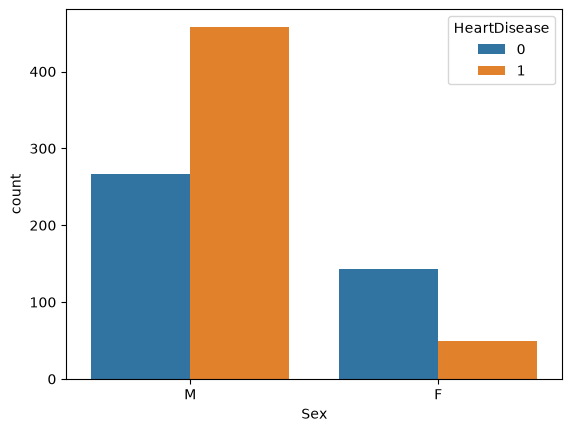

In [20]:
sns.countplot(x=df['Sex'], hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

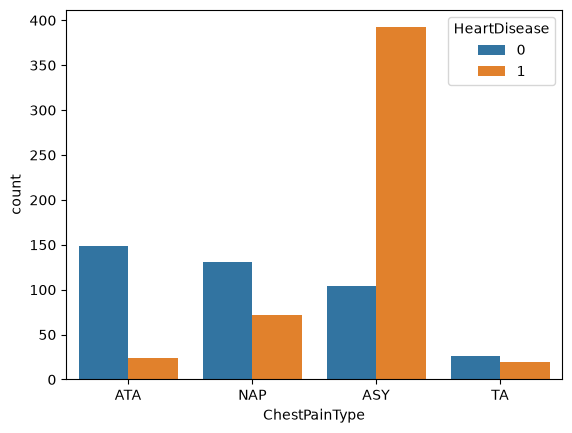

In [21]:
sns.countplot(x=df['ChestPainType'], hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

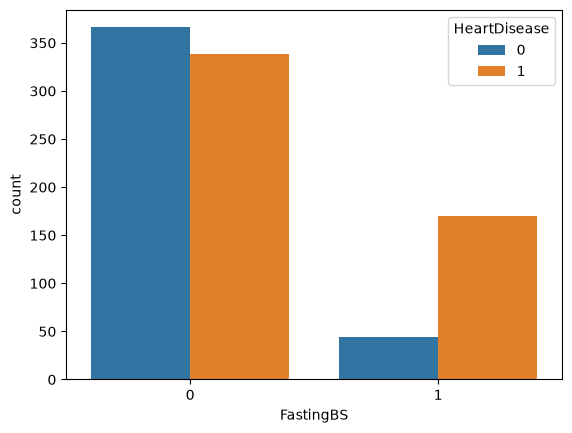

In [22]:
sns.countplot(x=df['FastingBS'], hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

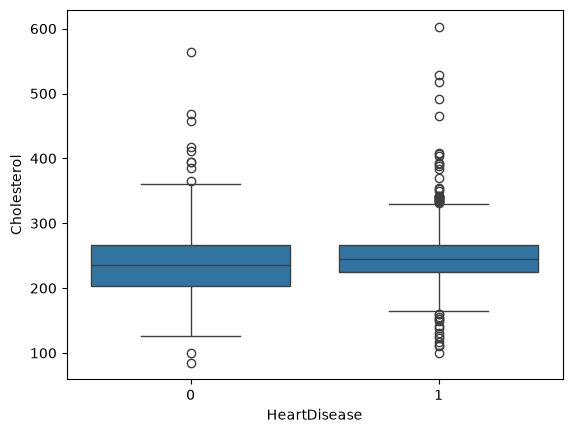

In [23]:
sns.boxplot(x=df['HeartDisease'],y=df['Cholesterol'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

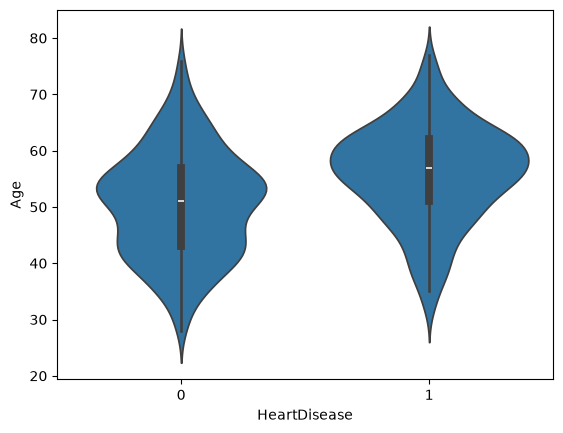

In [24]:
sns.violinplot(x='HeartDisease',y='Age',data=df)

<Axes: >

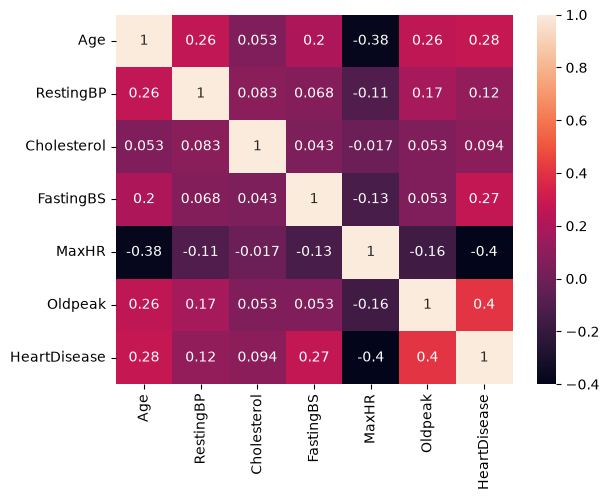

In [25]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Feature Engineering and Extraction

In [26]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 40, 50, 60, 70, 100],
    labels=["<40", "40-50", "50-60", "60-70", "70+"],
    right=False
)

In [27]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0,40-50
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1,40-50
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0,<40
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1,40-50
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0,50-60


In [28]:
df["ExpectedMaxHR"] = 220 - df["Age"]

df["MaxHR_Ratio"] = (
    df["MaxHR"] / df["ExpectedMaxHR"]
)

df["MaxHR_Deficit"] = (
    df["ExpectedMaxHR"] - df["MaxHR"]
)

In [29]:
df["ST_Depression"] = (
    df["Oldpeak"] > 0
).astype(int)

In [30]:
df["ExerciseStress"] = (
    (df["ExerciseAngina"] == "Y").astype(int)
    * df["Oldpeak"]
)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

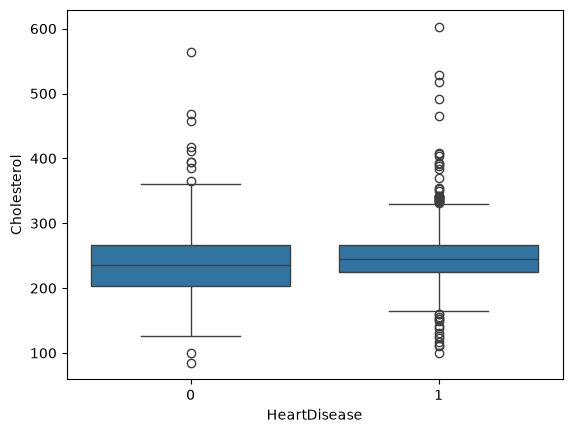

In [31]:
sns.boxplot(
    x=df['HeartDisease'],
    y=df['Cholesterol']
)

<Axes: >

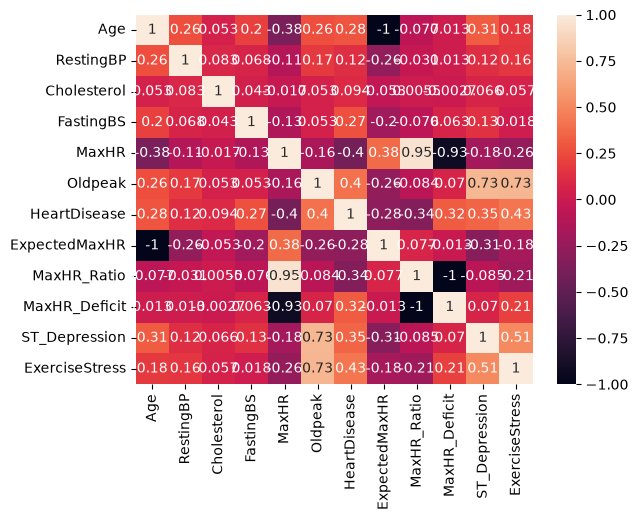

In [32]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

<Axes: xlabel='HeartDisease', ylabel='Age'>

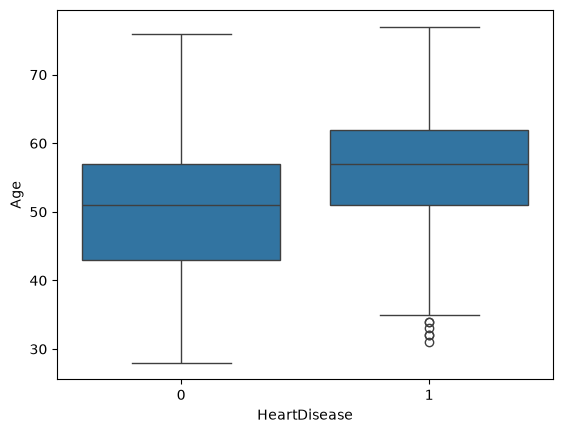

In [33]:
sns.boxplot(
    data=df,
    x="HeartDisease",
    y="Age"
)

<Axes: xlabel='HeartDisease', ylabel='Oldpeak'>

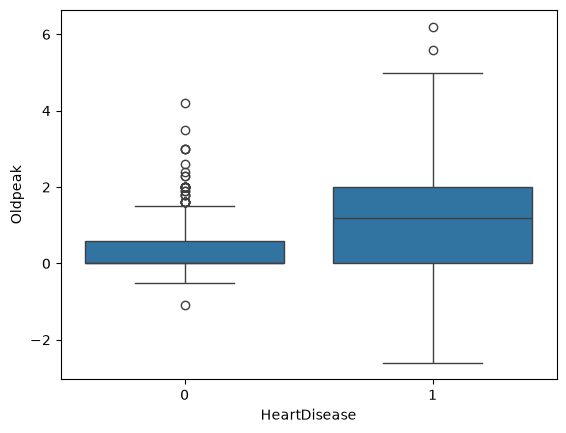

In [34]:
sns.boxplot(
    data=df,
    x="HeartDisease",
    y="Oldpeak"
)

In [35]:
pd.crosstab(
    df["ChestPainType"],
    df["HeartDisease"],
    normalize="index"
)

HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783


In [36]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [43]:
df["ST_Depression"] = (
    df["Oldpeak"] > 0
).astype(int)

In [44]:
df["Oldpeak_Level"] = pd.cut(
    df["Oldpeak"],
    bins=[-np.inf, 0, 1, 2, np.inf],
    labels=[
        "Negative",
        "Low",
        "Moderate",
        "High"
    ]
)

In [45]:
pd.crosstab(
    df["Oldpeak_Level"],
    df["HeartDisease"],
    normalize="index"
)

HeartDisease,0,1
Oldpeak_Level,,
Negative,0.650919,0.349081
Low,0.480392,0.519608
Moderate,0.236052,0.763948
High,0.090000,0.910000


In [46]:
df.groupby("HeartDisease")["Oldpeak"].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,410.0,0.408049,0.699709,-1.1,0.0,0.0,0.6,4.2
1,508.0,1.274213,1.151872,-2.6,0.0,1.2,2.0,6.2


In [47]:
pd.crosstab(
    df["ST_Slope"],
    df["HeartDisease"],
    normalize="index"
)

HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


In [54]:
pd.crosstab(
    df["AgeGroup"],
    df["HeartDisease"],
    normalize="index"
).round(3)

HeartDisease,0,1
AgeGroup,,
<40,0.675,0.325
40-50,0.597,0.403
50-60,0.433,0.567
60-70,0.266,0.734
70+,0.290,0.710


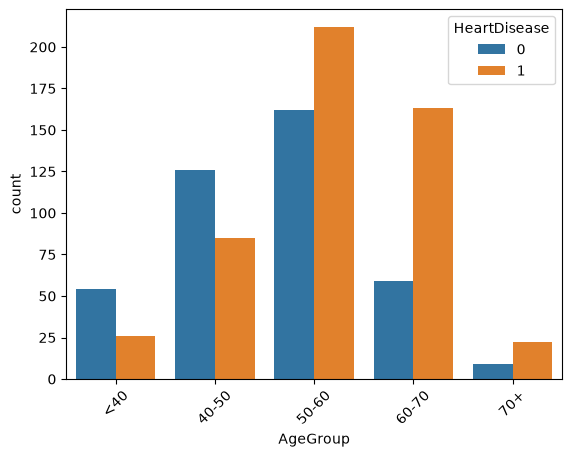

In [55]:
sns.countplot(
    data=df,
    x="AgeGroup",
    hue="HeartDisease"
)

plt.xticks(rotation=45)
plt.show()

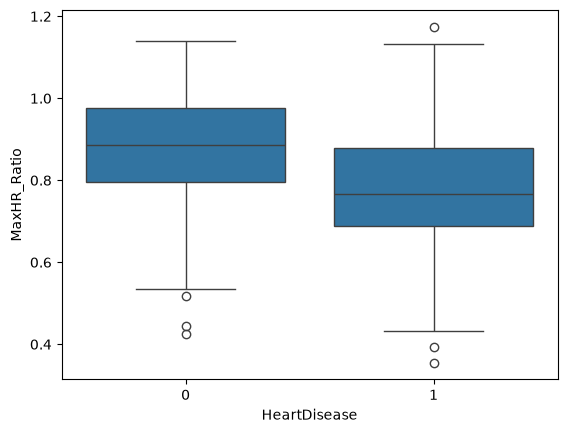

In [56]:
sns.boxplot(
    data=df,
    x="HeartDisease",
    y="MaxHR_Ratio"
)

plt.show()

In [57]:
df.groupby("HeartDisease")[
    "MaxHR_Ratio"
].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,410.0,0.874184,0.127846,0.425926,0.795890,0.886152,0.975384,1.140127
1,508.0,0.778273,0.138957,0.355030,0.689077,0.765432,0.878131,1.174699


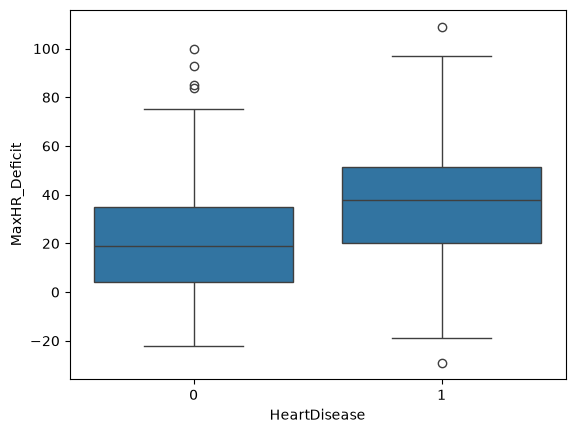

In [58]:
sns.boxplot(
    data=df,
    x="HeartDisease",
    y="MaxHR_Deficit"
)

plt.show()

In [59]:
df.groupby("HeartDisease")[
    "MaxHR_Deficit"
].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,410.0,21.297561,21.600264,-22.0,4.0,19.0,35.00,100.0
1,508.0,36.444882,22.856186,-29.0,20.0,38.0,51.25,109.0


In [60]:
df["ST_Depression"] = (
    df["Oldpeak"] > 0
).astype(int)

In [61]:
pd.crosstab(
    df["ST_Depression"],
    df["HeartDisease"],
    normalize="index"
).round(3)

HeartDisease,0,1
ST_Depression,,
0,0.651,0.349
1,0.302,0.698


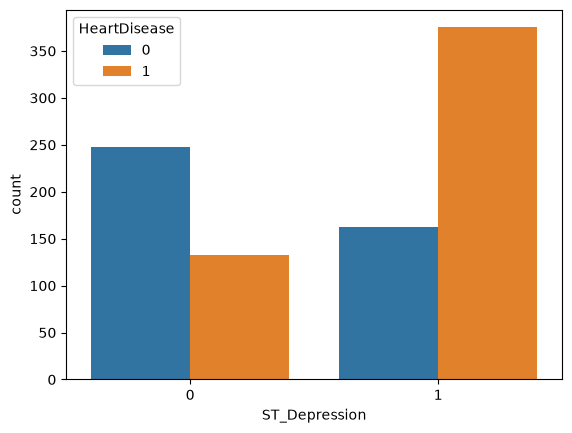

In [62]:
sns.countplot(
    data=df,
    x="ST_Depression",
    hue="HeartDisease"
)

plt.show()

In [63]:
df["ExerciseStress"] = (
    (df["ExerciseAngina"] == "Y").astype(int)
    * df["Oldpeak"]
)

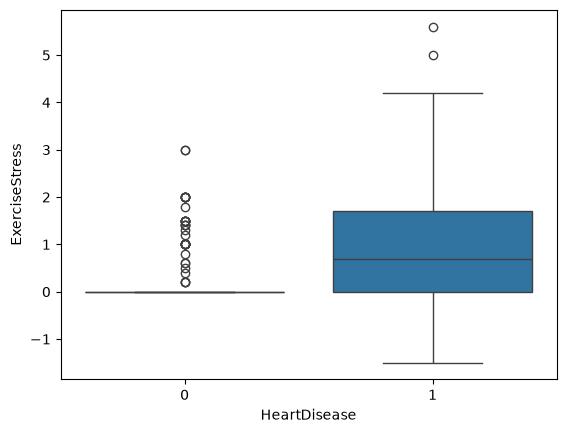

In [64]:
sns.boxplot(
    data=df,
    x="HeartDisease",
    y="ExerciseStress"
)

plt.show()

In [65]:
df.groupby("HeartDisease")[
    "ExerciseStress"
].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,410.0,0.117073,0.422533,0.0,0.0,0.0,0.0,3.0
1,508.0,0.939961,1.107388,-1.5,0.0,0.7,1.7,5.6


In [66]:
pd.crosstab(
    df["Oldpeak_Level"],
    df["HeartDisease"],
    normalize="index"
)

HeartDisease,0,1
Oldpeak_Level,,
Negative,0.650919,0.349081
Low,0.480392,0.519608
Moderate,0.236052,0.763948
High,0.090000,0.910000


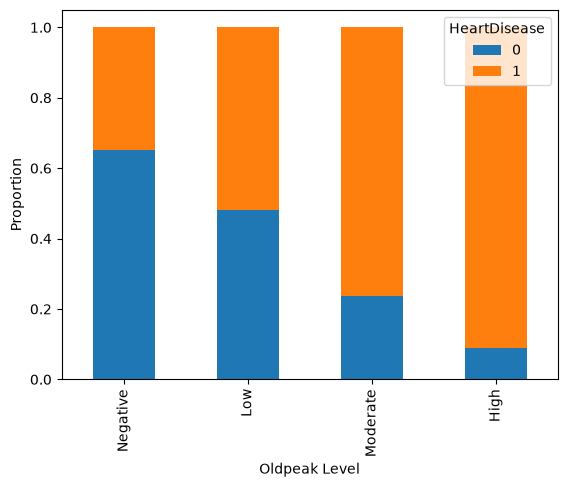

In [69]:
oldpeak_target = pd.crosstab(
    df["Oldpeak_Level"],
    df["HeartDisease"],
    normalize="index"
)

oldpeak_target.plot(
    kind="bar",
    stacked=True
)

plt.ylabel("Proportion")
plt.xlabel("Oldpeak Level")
plt.show()

In [70]:
df.corr(numeric_only=True)["HeartDisease"].sort_values(
    ascending=False
)

HeartDisease      1.000000
ExerciseStress    0.425544
Oldpeak           0.403951
ST_Depression     0.346141
MaxHR_Deficit     0.320196
Age               0.282039
FastingBS         0.267291
RestingBP         0.117938
Cholesterol       0.094082
ExpectedMaxHR    -0.282039
MaxHR_Ratio      -0.335320
MaxHR            -0.400421
Name: HeartDisease, dtype: float64

In [72]:
df.groupby("HeartDisease")[
    [
        "ExerciseStress",
        "Oldpeak",
        "ST_Depression",
        "MaxHR_Deficit",
        "Age",
        "FastingBS",
        "RestingBP",
        "Cholesterol",
        "MaxHR"
    ]
].mean()

,ExerciseStress,Oldpeak,ST_Depression,MaxHR_Deficit,Age,FastingBS,RestingBP,Cholesterol,MaxHR
HeartDisease,,,,,,,,,
0,0.117073,0.408049,0.395122,21.297561,50.551220,0.107317,130.180488,239.055610,148.151220
1,0.939961,1.274213,0.738189,36.444882,55.899606,0.334646,134.445945,249.140315,127.655512


In [73]:
df.groupby("HeartDisease")[
    [
        "ExerciseStress",
        "Oldpeak",
        "ST_Depression",
        "MaxHR_Deficit",
        "Age",
        "FastingBS",
        "RestingBP",
        "Cholesterol",
        "MaxHR"
    ]
].median()

,ExerciseStress,Oldpeak,ST_Depression,MaxHR_Deficit,Age,FastingBS,RestingBP,Cholesterol,MaxHR
HeartDisease,,,,,,,,,
0,0.0,0.0,0.0,19.0,51.0,0.0,130.0,235.00,150.0
1,0.7,1.2,1.0,38.0,57.0,0.0,132.0,244.64,126.0


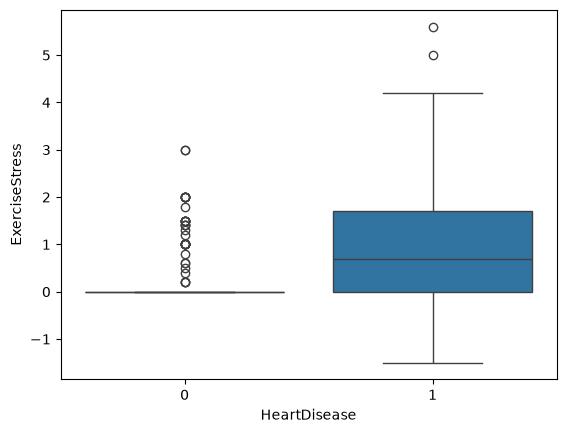

In [74]:
sns.boxplot(
    data=df,
    x="HeartDisease",
    y="ExerciseStress"
)

plt.show()

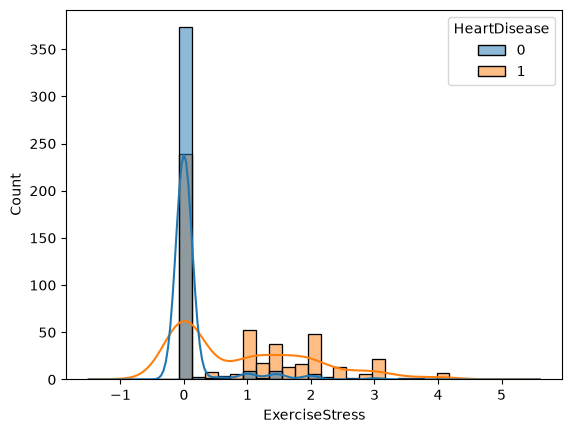

In [75]:
sns.histplot(
    data=df,
    x="ExerciseStress",
    hue="HeartDisease",
    kde=True
)

plt.show()

In [76]:
pd.crosstab(
    df["ChestPainType"],
    df["HeartDisease"],
    normalize="index"
).round(3)

HeartDisease,0,1
ChestPainType,,
ASY,0.210,0.790
ATA,0.861,0.139
NAP,0.645,0.355
TA,0.565,0.435


In [77]:
pd.crosstab(
    df["ST_Slope"],
    df["HeartDisease"],
    normalize="index"
).round(3)

HeartDisease,0,1
ST_Slope,,
Down,0.222,0.778
Flat,0.172,0.828
Up,0.803,0.197


In [78]:
pd.crosstab(
    df["ExerciseAngina"],
    df["HeartDisease"],
    normalize="index"
).round(3)

HeartDisease,0,1
ExerciseAngina,,
N,0.649,0.351
Y,0.148,0.852


In [71]:
from sklearn.feature_selection import mutual_info_classif

# Data Preprocessing


In [48]:
df_encode = pd.get_dummies(df)


In [49]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ExpectedMaxHR,MaxHR_Ratio,MaxHR_Deficit,...,ST_Slope_Up,AgeGroup_<40,AgeGroup_40-50,AgeGroup_50-60,AgeGroup_60-70,AgeGroup_70+,Oldpeak_Level_Negative,Oldpeak_Level_Low,Oldpeak_Level_Moderate,Oldpeak_Level_High
0,40,140.0,289.0,0,172,0.0,0,180,0.955556,8,...,True,False,True,False,False,False,True,False,False,False
1,49,160.0,180.0,0,156,1.0,1,171,0.912281,15,...,False,False,True,False,False,False,False,True,False,False
2,37,130.0,283.0,0,98,0.0,0,183,0.535519,85,...,True,True,False,False,False,False,True,False,False,False
3,48,138.0,214.0,0,108,1.5,1,172,0.627907,64,...,False,False,True,False,False,False,False,False,True,False
4,54,150.0,195.0,0,122,0.0,0,166,0.734940,44,...,True,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,175,0.754286,43,...,False,False,True,False,False,False,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,152,0.927632,11,...,False,False,False,False,True,False,False,False,False,True
915,57,130.0,131.0,0,115,1.2,1,163,0.705521,48,...,False,False,False,True,False,False,False,False,True,False
916,57,130.0,236.0,0,174,0.0,1,163,1.067485,-11,...,False,False,False,True,False,False,True,False,False,False


In [50]:
df_encode.astype(int)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ExpectedMaxHR,MaxHR_Ratio,MaxHR_Deficit,...,ST_Slope_Up,AgeGroup_<40,AgeGroup_40-50,AgeGroup_50-60,AgeGroup_60-70,AgeGroup_70+,Oldpeak_Level_Negative,Oldpeak_Level_Low,Oldpeak_Level_Moderate,Oldpeak_Level_High
0,40,140,289,0,172,0,0,180,0,8,...,1,0,1,0,0,0,1,0,0,0
1,49,160,180,0,156,1,1,171,0,15,...,0,0,1,0,0,0,0,1,0,0
2,37,130,283,0,98,0,0,183,0,85,...,1,1,0,0,0,0,1,0,0,0
3,48,138,214,0,108,1,1,172,0,64,...,0,0,1,0,0,0,0,0,1,0
4,54,150,195,0,122,0,0,166,0,44,...,1,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,175,0,43,...,0,0,1,0,0,0,0,0,1,0
914,68,144,193,1,141,3,1,152,0,11,...,0,0,0,0,1,0,0,0,0,1
915,57,130,131,0,115,1,1,163,0,48,...,0,0,0,1,0,0,0,0,1,0
916,57,130,236,0,174,0,1,163,1,-11,...,0,0,0,1,0,0,1,0,0,0


In [51]:
# Convert Boolean columns to 0/1
bool_columns = df_encode.select_dtypes(include='bool').columns
df_encode[bool_columns] = df_encode[bool_columns].astype(int)

# Standard scaling
from sklearn.preprocessing import StandardScaler

Numerical_Columns = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak'
]

scaler = StandardScaler()

df_encode[Numerical_Columns] = scaler.fit_transform(
    df_encode[Numerical_Columns]
)

df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ExpectedMaxHR,MaxHR_Ratio,MaxHR_Deficit,...,ST_Slope_Up,AgeGroup_<40,AgeGroup_40-50,AgeGroup_50-60,AgeGroup_60-70,AgeGroup_70+,Oldpeak_Level_Negative,Oldpeak_Level_Low,Oldpeak_Level_Moderate,Oldpeak_Level_High
0,-1.433140,0.414853,0.832513,0,1.382928,-0.832432,0,180,0.955556,8,...,1,0,1,0,0,0,1,0,0,0
1,-0.478484,1.527192,-1.212938,0,0.754157,0.105664,1,171,0.912281,15,...,0,0,1,0,0,0,0,1,0,0
2,-1.751359,-0.141317,0.719919,0,-1.525138,-0.832432,0,183,0.535519,85,...,1,1,0,0,0,0,1,0,0,0
3,-0.584556,0.303619,-0.574908,0,-1.132156,0.574711,1,172,0.627907,64,...,0,0,1,0,0,0,0,0,1,0
4,0.051881,0.971022,-0.931454,0,-0.581981,-0.832432,0,166,0.734940,44,...,1,0,0,1,0,0,1,0,0,0


In [52]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ExpectedMaxHR,MaxHR_Ratio,MaxHR_Deficit,...,ST_Slope_Up,AgeGroup_<40,AgeGroup_40-50,AgeGroup_50-60,AgeGroup_60-70,AgeGroup_70+,Oldpeak_Level_Negative,Oldpeak_Level_Low,Oldpeak_Level_Moderate,Oldpeak_Level_High
0,-1.433140,0.414853,0.832513,0,1.382928,-0.832432,0,180,0.955556,8,...,1,0,1,0,0,0,1,0,0,0
1,-0.478484,1.527192,-1.212938,0,0.754157,0.105664,1,171,0.912281,15,...,0,0,1,0,0,0,0,1,0,0
2,-1.751359,-0.141317,0.719919,0,-1.525138,-0.832432,0,183,0.535519,85,...,1,1,0,0,0,0,1,0,0,0
3,-0.584556,0.303619,-0.574908,0,-1.132156,0.574711,1,172,0.627907,64,...,0,0,1,0,0,0,0,0,1,0
4,0.051881,0.971022,-0.931454,0,-0.581981,-0.832432,0,166,0.734940,44,...,1,0,0,1,0,0,1,0,0,0


<Axes: xlabel='Age', ylabel='Count'>

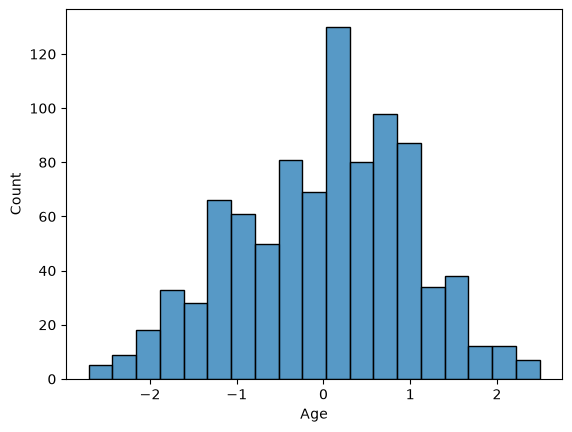

In [53]:
sns.histplot(df_encode['Age'])